# Group Pipeline: Adult Income Dataset — Combined Preprocessing

**Group ID:** 2026-Y2-S1-MLB-B1G1-07
**Course:** IT2011 - Artificial Intelligence and Machine Learning

This notebook integrates the six individual preprocessing techniques developed by each
group member into a single, logically-ordered pipeline that runs on the raw dataset and
produces one final, cleaned, model-ready dataset.

**Pipeline order:**
1. Missing value handling — Wickramasinghe G.D.M.H (IT25102064)
2. Duplicate removal & class imbalance check — Lakshan H.M.K (IT25101220)
3. Outlier detection & removal — Hansani J.A.T.H (IT25300345)
4. Feature engineering (redundancy removal) — Wickramasinghe M.P.T.H (IT25300115)
5. Encoding categorical variables — Wickrama W.M.K.E (IT25102219)
6. Feature scaling — Weerarathna N.H (IT25103014)

Each section below is a condensed version of that member's individual notebook,
adapted to chain onto the previous member's output instead of reloading the raw file.


## Setup
Load libraries and the raw dataset.

In [32]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['font.family'] = 'sans-serif'

DATA_RAW_PATH = Path('data/raw/adult.csv')
FIG_DIR = Path('results/eda_visualizations')
OUT_DIR = Path('results/outputs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_RAW_PATH)
print(f"Raw dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Standardize string whitespace and convert '?' placeholders to NaN
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()
df.replace('?', np.nan, inplace=True)
print("Whitespace stripped and '?' placeholders converted to NaN.")


Raw dataset loaded: 32,561 rows, 15 columns
Whitespace stripped and '?' placeholders converted to NaN.


## Step 1: Handling Missing Data
**Member:** Wickramasinghe G.D.M.H | IT25102064

`workclass`, `occupation`, and `native.country` contain missing values (marked '?' in the
raw data, now NaN). All three are categorical, so mean/median imputation doesn't apply.
Mode imputation is used to preserve the full row count rather than dropping ~7% of rows.


In [33]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print("Missing values before imputation:")
print(missing_before)

for col in ['workclass', 'occupation', 'native.country']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"'{col}' imputed with mode value: '{mode_value}'")

missing_after = df.isnull().sum().sum()
print(f"\nRemaining missing values after imputation: {missing_after}")
assert missing_after == 0, "Missing values remain!"


Missing values before imputation:
workclass         1836
occupation        1843
native.country     583
dtype: int64
'workclass' imputed with mode value: 'Private'
'occupation' imputed with mode value: 'Prof-specialty'
'native.country' imputed with mode value: 'United-States'

Remaining missing values after imputation: 0


## Step 2: Duplicate Removal & Class Imbalance Check
**Member:** Lakshan H.M.K | IT25101220

Exact duplicate rows are removed to prevent data leakage and inflated confidence.
The target variable `income` is then checked for class imbalance, since this informs
evaluation strategy later (Step 4 of the assignment).


In [34]:
rows_before = len(df)
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f"Rows before: {rows_before:,}")
print(f"Exact duplicates removed: {duplicate_count:,}")
print(f"Rows after: {rows_after:,}")

target_counts = df['income'].value_counts()
target_pct = df['income'].value_counts(normalize=True) * 100
print("\nTarget class distribution:")
for cls in target_counts.index:
    print(f"  {cls}: {target_counts[cls]:,} ({target_pct[cls]:.2f}%)")

imbalance_ratio = target_counts['<=50K'] / target_counts['>50K']
print(f"\nClass imbalance ratio (<=50K : >50K): {imbalance_ratio:.2f} : 1")
print("Note: stratified train/test splitting and F1/precision/recall metrics")
print("(rather than raw accuracy) should be used downstream given this imbalance.")


Rows before: 32,561
Exact duplicates removed: 24
Rows after: 32,537

Target class distribution:
  <=50K: 24,698 (75.91%)
  >50K: 7,839 (24.09%)

Class imbalance ratio (<=50K : >50K): 3.15 : 1
Note: stratified train/test splitting and F1/precision/recall metrics
(rather than raw accuracy) should be used downstream given this imbalance.


## Step 3: Outlier Detection & Removal
**Member:** Hansani J.A.T.H | IT25300345

`capital.gain` and `capital.loss` are extremely right-skewed (mostly 0, with a long tail),
so a standard IQR rule would flag almost all non-zero values as outliers. Instead, only
values above the 99.5th percentile in `capital.gain`, `capital.loss`, and `hours.per.week`
are removed — a conservative rule that retains 99.5% of observations per feature while
dropping only the most extreme upper-tail cases.


In [35]:
outlier_cols = ['capital.gain', 'capital.loss', 'hours.per.week']

PERCENTILE = 0.995
outlier_mask = pd.Series(False, index=df.index)
thresholds = {}

for col in outlier_cols:
    threshold = df[col].quantile(PERCENTILE)
    thresholds[col] = threshold
    col_mask = df[col] > threshold
    outlier_mask = outlier_mask | col_mask
    print(f"{col}: 99.5th percentile threshold = {threshold:.2f}, "
          f"rows flagged = {col_mask.sum()}")

rows_before_outliers = len(df)
df = df.loc[~outlier_mask].copy()
df.reset_index(drop=True, inplace=True)
rows_after_outliers = len(df)

print(f"\nRows before outlier removal: {rows_before_outliers:,}")
print(f"Rows removed: {rows_before_outliers - rows_after_outliers:,}")
print(f"Rows after outlier removal: {rows_after_outliers:,}")


capital.gain: 99.5th percentile threshold = 34095.00, rows flagged = 161
capital.loss: 99.5th percentile threshold = 2260.88, rows flagged = 163
hours.per.week: 99.5th percentile threshold = 84.00, rows flagged = 159

Rows before outlier removal: 32,537
Rows removed: 479
Rows after outlier removal: 32,058


## Step 4: Feature Engineering — Redundancy Removal
**Member:** Wickramasinghe M.P.T.H | IT25300115

`education` and `education.num` are two representations of the same attribute
(`education.num` is an exact integer rank encoding of `education`). Keeping both would
duplicate the same information, so the redundant categorical version (`education`) is
dropped in favor of the already-numeric `education.num`.


Dropped redundant 'education' column (duplicate of 'education.num').
Columns: 15 -> 14


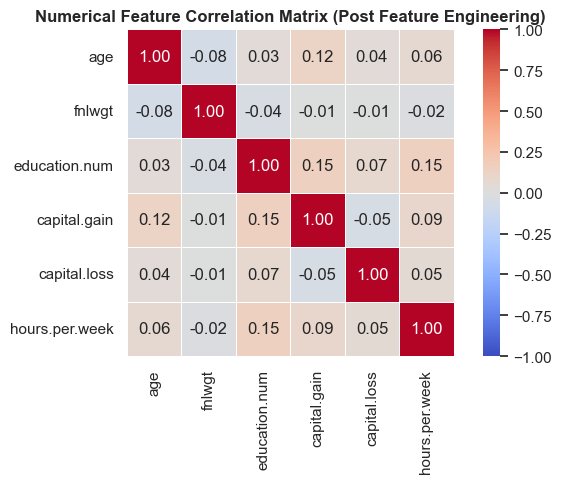

No numerical features show strong enough correlation to warrant further removal.


In [36]:
cols_before = df.shape[1]
df.drop(columns=['education'], inplace=True)
cols_after = df.shape[1]
print(f"Dropped redundant 'education' column (duplicate of 'education.num').")
print(f"Columns: {cols_before} -> {cols_after}")

num_features = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_features].corr(method='pearson')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix (Post Feature Engineering)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'Group_Pipeline_Correlation_Heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("No numerical features show strong enough correlation to warrant further removal.")


## Step 5: Encoding Categorical Variables
**Member:** Wickrama W.M.K.E | IT25102219

The target `income` is label-encoded to a binary 0/1. The remaining nominal categorical
features (`workclass`, `marital.status`, `occupation`, `relationship`, `race`, `sex`,
`native.country`) are one-hot encoded, since they have no inherent order.


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])
print("'income' encoded (0 = <=50K, 1 = >50K)")
print(df['income'].value_counts())

nominal_cols = ['workclass', 'marital.status', 'occupation',
                 'relationship', 'race', 'sex', 'native.country']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
print(f"\nData one-hot encoded. Final column count: {df.shape[1]}")


'income' encoded (0 = <=50K, 1 = >50K)
income
0    24532
1     7526
Name: count, dtype: int64

Data one-hot encoded. Final column count: 83


## Step 6: Feature Scaling
**Member:** Weerarathna N.H | IT25103014

Numerical features have very different scales (e.g. `age`: 17–90 vs. `fnlwgt`: ~12,000–
1,484,705), which affects distance- and gradient-based models such as Logistic Regression
or SVM. `StandardScaler` is applied to standardize these features to zero mean / unit
variance. Note: tree-based models (Random Forest, Decision Trees) are scale-invariant and
do not require this step — it is included here so scaled features are available for
whichever models the group's Step 3 modeling stage selects.


In [38]:
numeric_features = ['age', 'fnlwgt', 'education.num', 'capital.gain',
                     'capital.loss', 'hours.per.week']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

print("Numeric features scaled (mean=0, std=1):")
print(df[numeric_features].describe().round(2))


Numeric features scaled (mean=0, std=1):
            age    fnlwgt  education.num  capital.gain  capital.loss  \
count  32058.00  32058.00       32058.00      32058.00      32058.00   
mean      -0.00      0.00           0.00         -0.00          0.00   
std        1.00      1.00           1.00          1.00          1.00   
min       -1.58     -1.68          -3.54         -0.23         -0.21   
25%       -0.77     -0.68          -0.41         -0.23         -0.21   
50%       -0.11     -0.11          -0.02         -0.23         -0.21   
75%        0.63      0.45           0.76         -0.23         -0.21   
max        3.78     12.26           2.32         13.15          5.99   

       hours.per.week  
count        32058.00  
mean             0.00  
std              1.00  
min             -3.34  
25%             -0.01  
50%             -0.01  
75%              0.42  
max              3.75  


## Final Output
Save the fully preprocessed, encoded, scaled dataset — ready for model training in
Step 3 of the assignment.


In [39]:
output_path = OUT_DIR / 'adult_processed.csv'
df.to_csv(output_path, index=False)

print(f"Final processed dataset saved to: {output_path.resolve()}")
print(f"Final shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()


Final processed dataset saved to: C:\Users\Malan\Downloads\2026-Y2-S1-MLB-B1G1-07\results\outputs\adult_processed.csv
Final shape: 32,058 rows, 83 columns


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.360450,1.712817,-0.41443,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-1.356863,-0.310543,-0.02313,-0.232725,5.989283,-2.567806,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.402131,0.935970,-0.41443,-0.232725,5.989283,3.745241,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,-0.622454,0.637500,-0.02313,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.111955,0.928000,1.15077,-0.232725,5.989283,0.674029,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
